# WiFiスニッフィング消費電流解析

nrf_wifi_power_test.ino で取得した電流データを解析する。

**測定パターン**: 1秒, 3秒, 5秒, 10秒 × 各10回

**解析内容**:
- 電流波形の可視化
- ESP32電源ON区間の自動検出（閾値ベース）
- 各スキャン時間パターンごとの平均電流・ピーク電流
- ベースライン電流（ESP32 OFF時）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 日本語フォント設定
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 設定
# ============================================================
CSV_FILE = 'dist/current_log.csv'  # 電流測定データ

# 測定時間範囲
START_TIME = '2026-03-16 18:40:40'
END_TIME = '2026-03-16 18:50:00'

# ESP32 ON/OFF 検出の閾値 (mA)
ON_THRESHOLD_MA = 30.0

# 測定パターン (nrf_wifi_power_test.ino と一致させる)
SCAN_PATTERNS_MS = [1000, 3000, 5000, 10000]
REPS_PER_PATTERN = 10

In [2]:
# ============================================================
# データ読み込み
# ============================================================
df = pd.read_csv(CSV_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 時間範囲でフィルタ
if START_TIME:
    df = df[df['Timestamp'] >= pd.to_datetime(START_TIME)]
if END_TIME:
    df = df[df['Timestamp'] <= pd.to_datetime(END_TIME)]

df = df.reset_index(drop=True)

# 経過時間 (秒)
df['elapsed_s'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

print(f'データ件数: {len(df)}')
print(f'時間範囲: {df["Timestamp"].iloc[0]} ~ {df["Timestamp"].iloc[-1]}')
print(f'サンプリング間隔: {df["elapsed_s"].diff().median()*1000:.1f} ms')

データ件数: 10614
時間範囲: 2026-03-16 18:40:40.119089 ~ 2026-03-16 18:49:59.967259
サンプリング間隔: 50.8 ms


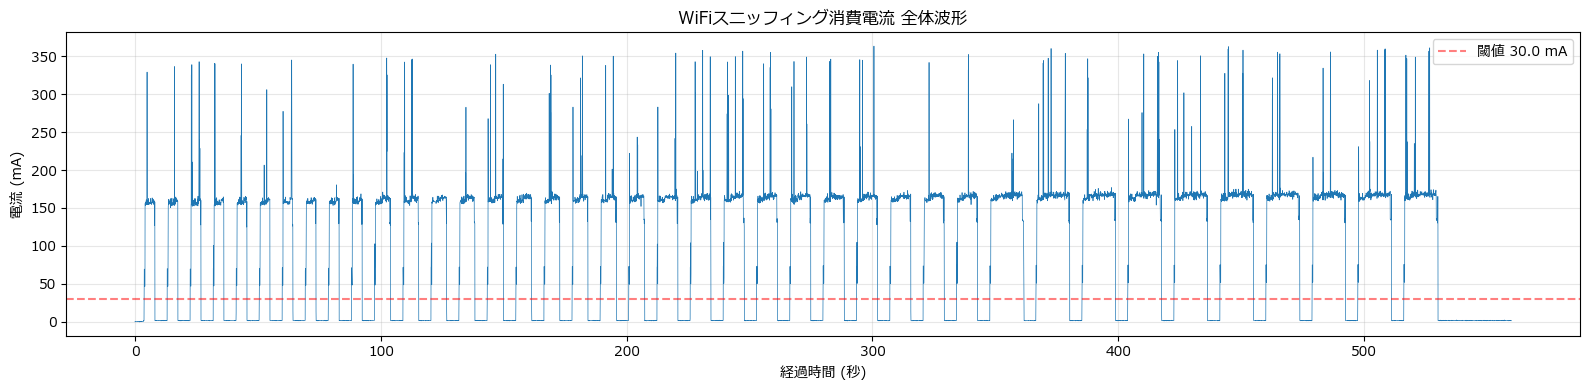

In [3]:
# ============================================================
# 全体の電流波形
# ============================================================
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['elapsed_s'], df['Current (mA)'], linewidth=0.5)
ax.set_xlabel('経過時間 (秒)')
ax.set_ylabel('電流 (mA)')
ax.set_title('WiFiスニッフィング消費電流 全体波形')
ax.axhline(y=ON_THRESHOLD_MA, color='r', linestyle='--', alpha=0.5, label=f'閾値 {ON_THRESHOLD_MA} mA')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# ESP32 ON区間の自動検出
# ============================================================
current = df['Current (mA)'].values
timestamps = df['elapsed_s'].values

# 閾値を超えている区間を検出
is_on = current > ON_THRESHOLD_MA

# ON区間の開始・終了インデックスを検出
transitions = np.diff(is_on.astype(int))
on_starts = np.where(transitions == 1)[0] + 1
on_ends = np.where(transitions == -1)[0] + 1

# 先頭がONで始まる場合の補正
if is_on[0]:
    on_starts = np.insert(on_starts, 0, 0)
# 末尾がONで終わる場合の補正
if is_on[-1]:
    on_ends = np.append(on_ends, len(is_on))

# ペアにする
n_cycles = min(len(on_starts), len(on_ends))
on_starts = on_starts[:n_cycles]
on_ends = on_ends[:n_cycles]

# 短すぎるスパイク（1秒未満）を除外
valid = []
for s, e in zip(on_starts, on_ends):
    duration = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    if duration >= 1.0:
        valid.append((s, e))

print(f'検出されたON区間: {len(valid)} 回')
print(f'期待値: {len(SCAN_PATTERNS_MS) * REPS_PER_PATTERN} 回')

if len(valid) != len(SCAN_PATTERNS_MS) * REPS_PER_PATTERN:
    print('\n*** 警告: 検出数が期待値と一致しません ***')
    print('ON_THRESHOLD_MA の値を調整するか、START_TIME/END_TIME で範囲を絞ってください')

検出されたON区間: 40 回
期待値: 40 回


In [ ]:
# ============================================================
# 各ON区間の統計 (待機 vs スニフィング, ベースライン差し引き)
# ============================================================
WARMUP_S = 3.0  # ESP ON後、スニフィング開始までの待機時間 (秒)

# 先にベースライン算出
all_on_indices = set()
for s, e in valid:
    all_on_indices.update(range(s, e))
off_mask = ~df.index.isin(all_on_indices)
baseline = df.loc[off_mask, 'Current (mA)'].mean()
print(f'ベースライン電流 (ESP32 OFF): {baseline:.2f} mA\n')

results = []
total_expected = len(SCAN_PATTERNS_MS) * REPS_PER_PATTERN

for i, (s, e) in enumerate(valid):
    segment = df.iloc[s:e]
    t = segment['elapsed_s'].values - segment['elapsed_s'].values[0]
    current = segment['Current (mA)'].values
    duration_s = t[-1] - t[0]
    
    # 待機区間 (0 ~ WARMUP_S) - ベースライン差し引き
    warmup_mask = t < WARMUP_S
    warmup_mean = current[warmup_mask].mean() - baseline if warmup_mask.any() else np.nan
    
    # スニフィング区間 (WARMUP_S ~) - ベースライン差し引き
    sniff_mask = t >= WARMUP_S
    sniff_mean = current[sniff_mask].mean() - baseline if sniff_mask.any() else np.nan
    
    # パターンの割り当て
    if i < total_expected:
        pattern_idx = i // REPS_PER_PATTERN
        rep_idx = i % REPS_PER_PATTERN
        scan_ms = SCAN_PATTERNS_MS[pattern_idx] if pattern_idx < len(SCAN_PATTERNS_MS) else -1
    else:
        scan_ms = -1
        rep_idx = i
    
    results.append({
        'cycle': i + 1,
        'scan_ms': scan_ms,
        'rep': rep_idx + 1,
        'duration_s': duration_s,
        'mean_mA': segment['Current (mA)'].mean() - baseline,
        'warmup_mA': warmup_mean,
        'sniff_mA': sniff_mean,
        'peak_mA': segment['Current (mA)'].max() - baseline,
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

In [ ]:
# ============================================================
# パターンごとの集計 (ベースライン差し引き済み)
# ============================================================
summary = df_results.groupby('scan_ms').agg(
    回数=('mean_mA', 'count'),
    ON区間_平均秒=('duration_s', 'mean'),
    待機時電流_mA=('warmup_mA', 'mean'),
    スニフィング時電流_mA=('sniff_mA', 'mean'),
    全体平均電流_mA=('mean_mA', 'mean'),
    電流標準偏差_mA=('mean_mA', 'std'),
    ピーク電流_mA=('peak_mA', 'max'),
).reset_index()
summary.columns = ['スキャン時間(ms)', '回数', 'ON区間平均(秒)',
                    '待機時電流(mA)', 'スニフィング時電流(mA)',
                    '全体平均電流(mA)', '標準偏差(mA)', 'ピーク電流(mA)']

print('=== パターンごとの集計 (ベースライン差し引き済み) ===')
print(summary.to_string(index=False))
print(f'\n※ ベースライン {baseline:.2f} mA を差し引いた値')

# 待機 vs スニフィングの全体平均
warmup_avg = df_results['warmup_mA'].mean()
sniff_avg = df_results['sniff_mA'].mean()
print(f'\nESP32 ON 待機時平均電流: {warmup_avg:.1f} mA')
print(f'WiFiスニフィング時平均電流: {sniff_avg:.1f} mA')
print(f'スニフィングによる増加分: {sniff_avg - warmup_avg:.1f} mA')

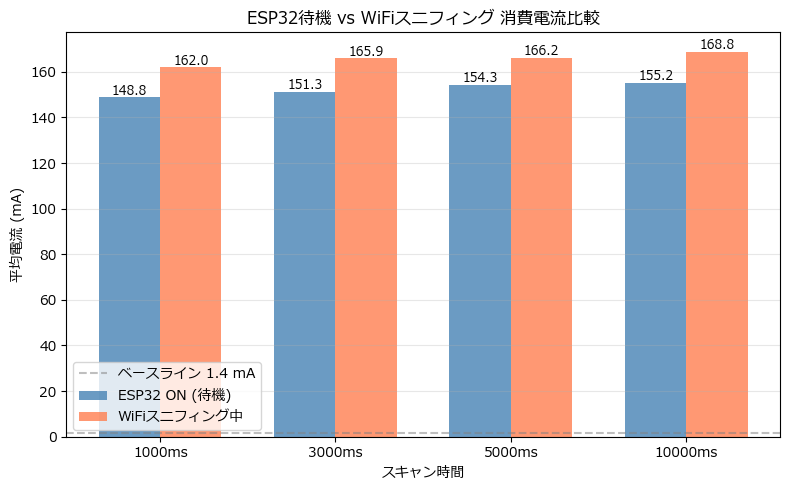

In [7]:
# ============================================================
# 待機 vs スニフィング 消費電流比較グラフ
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

valid_summary = summary[summary['スキャン時間(ms)'] > 0]
x = np.arange(len(valid_summary))
width = 0.35

bars1 = ax.bar(x - width/2, valid_summary['待機時電流(mA)'].values, width,
               label='ESP32 ON (待機)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, valid_summary['スニフィング時電流(mA)'].values, width,
               label='WiFiスニフィング中', color='coral', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'{int(v)}ms' for v in valid_summary['スキャン時間(ms)'].values])
ax.set_xlabel('スキャン時間')
ax.set_ylabel('平均電流 (mA)')
ax.set_title('ESP32待機 vs WiFiスニフィング 消費電流比較')
ax.axhline(y=baseline, color='gray', linestyle='--', alpha=0.5, label=f'ベースライン {baseline:.1f} mA')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 値ラベル
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

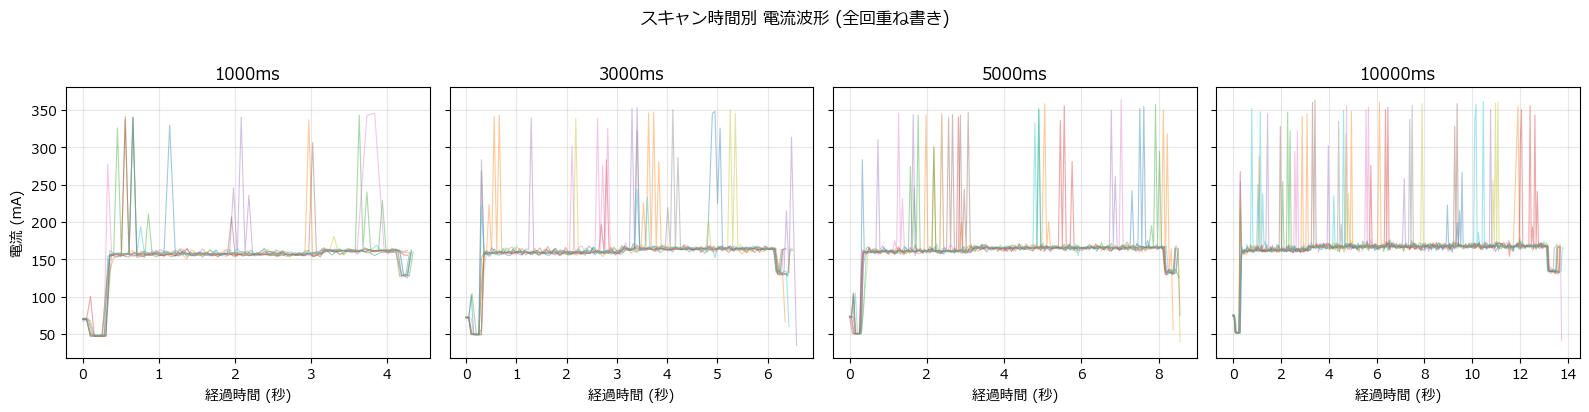

In [8]:
# ============================================================
# 各パターンの代表的な電流波形 (重ね書き)
# ============================================================
fig, axes = plt.subplots(1, len(SCAN_PATTERNS_MS), figsize=(16, 4), sharey=True)

for pidx, scan_ms in enumerate(SCAN_PATTERNS_MS):
    ax = axes[pidx]
    start_rep = pidx * REPS_PER_PATTERN
    end_rep = start_rep + REPS_PER_PATTERN
    
    for i in range(start_rep, min(end_rep, len(valid))):
        s, e = valid[i]
        segment = df.iloc[s:e]
        t = segment['elapsed_s'].values - segment['elapsed_s'].values[0]
        ax.plot(t, segment['Current (mA)'].values, alpha=0.4, linewidth=0.8)
    
    ax.set_title(f'{scan_ms}ms')
    ax.set_xlabel('経過時間 (秒)')
    if pidx == 0:
        ax.set_ylabel('電流 (mA)')
    ax.grid(True, alpha=0.3)

fig.suptitle('スキャン時間別 電流波形 (全回重ね書き)', y=1.02)
plt.tight_layout()
plt.show()